In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

import statsmodels.api as sm
import statsmodels.tsa.stattools as ts

from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.vector_ar.vecm import coint_johansen

In [2]:
def print_time(unix):
    dt = date.fromtimestamp(unix)
    ft = dt.strftime('%Y-%m-%d')
    print(ft)

In [3]:
print_time(1724889600)

2024-08-29


# Helper

In [ ]:
def split

# Get daily stock info

## Call API

In [4]:
def get_daily_stock_info(symbol, fr, to):
    # call API
    s = requests.Session()
    resp = s.get(
        'https://iboard-api.ssi.com.vn/statistics/charts/history',
        params={
            "resolution": "1D",
            "symbol": symbol,
            "from": fr,
            "to": to,
        },
        headers={
            "User-Agent": "PostmanRuntime/7.41.2"
        }
    )
    return resp.json()

## Transform to df

In [39]:
def stock_info_to_df(inf):
    columns = {
        't':'datetime',
        'c': 'close',
        'o': 'open',
        'h': 'high',
        'l': 'low',
        'v': 'volumn',
        's': 'status'
    }
    # symbol, open, close, high, low, volumn
    df = pd.DataFrame(inf['data'])
    df.rename(columns=columns, inplace=True)
    # transform unix time to datetime
    df['datetime'] = pd.to_datetime(df['datetime'], unit='s')
    # indexing
    df.set_index('datetime', inplace=True)
    return df

## Fetch

In [41]:
def get_stock_info(symbol, fr, to):
    inf = get_daily_stock_info(symbol,fr,to)
    return stock_info_to_df(inf)

In [55]:
fr = 1420070400 # 01/01/2015
to = 1724889600 # 29/08/2024

ins1 = 'FUESSV30'
ins2 = 'E1VFVN30'

raw_ins1 = get_stock_info(ins1, fr, to)
raw_ins2 = get_stock_info(ins2, fr, to)

In [56]:
close_ins1 = raw_ins1['close'].rename(ins1)
close_ins2 = raw_ins2['close'].rename(ins2)
all_ins = pd.merge(close_ins1, close_ins2, on="datetime", how="outer")
all_ins

,FUESSV30,E1VFVN30
datetime,,
2015-01-05,NaN,9.40
2015-01-06,NaN,9.40
2015-01-07,NaN,9.40
2015-01-08,NaN,9.30
2015-01-09,NaN,9.50
...,...,...
2024-08-23,16.43,23.07
2024-08-26,16.42,23.05
2024-08-27,16.45,23.09


<Axes: xlabel='datetime'>

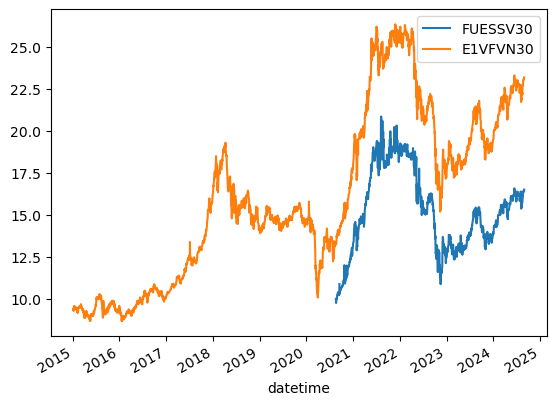

In [57]:
all_ins.plot()

In [ ]:
# Split train, test dataset

In [68]:
from sklearn.model_selection import train_test_split
tscv = TimeSeriesSplit(n_splits=5)
tscv
# DROP NA
all_data = all_ins.dropna()
train, test = train_test_split(all_data.sort_index(), test_size=0.2, shuffle=False)
train_folds = list(tscv.split(train))

# Cointegration on train data

In [80]:
# last fold
(ins_idx, ins_val_idx) = train_folds[-1]
ins, ins_val = train.iloc[ins_idx], train.iloc[ins_val_idx]
ins

,FUESSV30,E1VFVN30
datetime,,
2020-08-18,10.00,13.28
2020-08-19,9.82,13.30
2020-08-20,9.77,13.25
2020-08-21,9.86,13.31
2020-08-24,10.04,13.58
...,...,...
2023-04-20,13.06,18.06
2023-04-21,13.79,17.89
2023-04-24,12.86,17.90


In [70]:
# cointegration analysis: ins is a dataframe of n series
jres = coint_johansen(ins, det_order=0, k_ar_diff=1)
print(f'Eigen statistic: \n\t{jres.max_eig_stat}')
print(f'Eigen statistic critical: \n\t{jres.max_eig_stat_crit_vals}')
print(f'Eigen vector: \n\t{jres.evec.T}')
print(f'Eigen value: \n\t{jres.eig}')

Eigen statistic: 
	[94.45087502  4.1797747 ]
Eigen statistic critical: 
	[[12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]
Eigen vector: 
	[[ 2.95507152 -2.29915181]
 [ 0.16438526  0.16197224]]
Eigen value: 
	[0.11083834 0.00518523]


In [71]:
w1, w2 = jres.evec.T
weights = pd.DataFrame([w1] * len(ins) , columns=ins.columns, index=ins.index)
weights

,FUESSV30,E1VFVN30
datetime,,
2020-08-18,2.955072,-2.299152
2020-08-19,2.955072,-2.299152
2020-08-20,2.955072,-2.299152
2020-08-21,2.955072,-2.299152
2020-08-24,2.955072,-2.299152
...,...,...
2023-11-01,2.955072,-2.299152
2023-11-02,2.955072,-2.299152
2023-11-03,2.955072,-2.299152


In [73]:
spread = (weights * ins).sum(axis=1)
spread

datetime
2020-08-18   -0.982021
2020-08-19   -1.559917
2020-08-20   -1.592713
2020-08-21   -1.464705
2020-08-24   -1.553564
                ...   
2023-11-01   -3.776751
2023-11-02   -3.451968
2023-11-03   -3.192708
2023-11-06   -3.048406
2023-11-07   -3.159912
Length: 806, dtype: float64

In [74]:
zscore_spread = (spread - spread.mean()) / spread.std()
zscore_spread.describe()

count    806.000000
mean       0.000000
std        1.000000
min       -3.067835
25%       -0.663982
50%       -0.139826
75%        0.508449
max        6.496355
dtype: float64

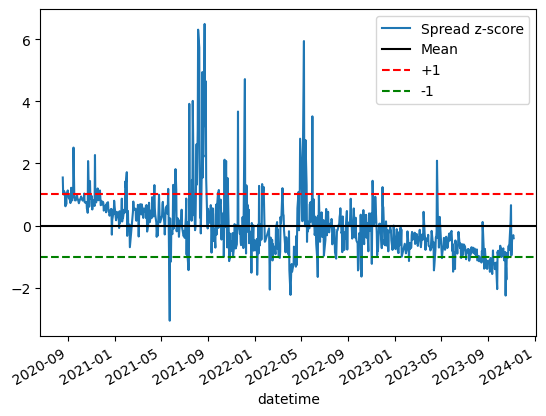

In [75]:
zscore_spread.plot()
plt.axhline(zscore_spread.mean(), color="black")
plt.axhline(1.0, color="red", linestyle="--")
plt.axhline(-1.0, color="green", linestyle="--")
plt.legend(["Spread z-score", "Mean", "+1", "-1"]);

In [76]:
x = spread.shift().dropna()
y = spread - spread.shift()
y = y.dropna()
x = sm.add_constant(x)
results = sm.OLS(y, x).fit()
halflife = -math.log(2) / results.params[0]
print('Halflife: %f' % halflife)

Halflife: 1.805915


# Backtest on validation data

In [81]:
price = ins_val
price

,FUESSV30,E1VFVN30
datetime,,
2023-04-27,12.76,17.78
2023-04-28,13.35,18.20
2023-05-04,12.64,17.93
2023-05-05,12.76,18.00
2023-05-08,12.85,18.00
...,...,...
2023-11-01,12.96,18.30
2023-11-02,13.35,18.66
2023-11-03,13.57,18.83


In [83]:
hedge_ratio = pd.DataFrame(np.nan,columns=price.columns,index=price.index)
hedge_ratio

,FUESSV30,E1VFVN30
datetime,,
2023-04-27,NaN,NaN
2023-04-28,NaN,NaN
2023-05-04,NaN,NaN
2023-05-05,NaN,NaN
2023-05-08,NaN,NaN
...,...,...
2023-11-01,NaN,NaN
2023-11-02,NaN,NaN
2023-11-03,NaN,NaN


In [94]:
lookback = 20
for i in range(lookback-1,len(price)):
    price_period = price[i-lookback+1:i+1]
    jres = coint_johansen(price_period, det_order=0, k_ar_diff=1)
    hedge_ratio.iloc[i] = jres.evec.T[0]
hedge_ratio

,FUESSV30,E1VFVN30
datetime,,
2023-04-27,NaN,NaN
2023-04-28,NaN,NaN
2023-05-04,NaN,NaN
2023-05-05,NaN,NaN
2023-05-08,2.436455e+15,-1.949164e+16
...,...,...
2023-11-01,7.202012e+00,-3.407822e+00
2023-11-02,7.588412e+00,-4.019126e+00
2023-11-03,6.947579e+00,-3.681493e+00


In [95]:
market_val = hedge_ratio * price
market_val

,FUESSV30,E1VFVN30
datetime,,
2023-04-27,NaN,NaN
2023-04-28,NaN,NaN
2023-05-04,NaN,NaN
2023-05-05,NaN,NaN
2023-05-08,3.130845e+16,-3.508496e+17
...,...,...
2023-11-01,9.333807e+01,-6.236314e+01
2023-11-02,1.013053e+02,-7.499689e+01
2023-11-03,9.427865e+01,-6.932251e+01


In [96]:
spread = market_val.sum(axis=1)
spread

datetime
2023-04-27    0.000000e+00
2023-04-28    0.000000e+00
2023-05-04    0.000000e+00
2023-05-05    0.000000e+00
2023-05-08   -3.195411e+17
                  ...     
2023-11-01    3.097493e+01
2023-11-02    2.630842e+01
2023-11-03    2.495614e+01
2023-11-06    2.879441e+01
2023-11-07    3.388344e+01
Length: 134, dtype: float64

In [97]:
num_units = -(spread - spread.rolling(lookback).mean()) / spread.rolling(lookback).std()
num_units

datetime
2023-04-27             NaN
2023-04-28             NaN
2023-05-04             NaN
2023-05-05             NaN
2023-05-08             NaN
                  ...     
2023-11-01    2.122914e-09
2023-11-02    2.185270e-09
2023-11-03    2.213058e-09
2023-11-06    2.184016e-09
2023-11-07    2.138242e-09
Length: 134, dtype: float64

<Axes: xlabel='datetime'>

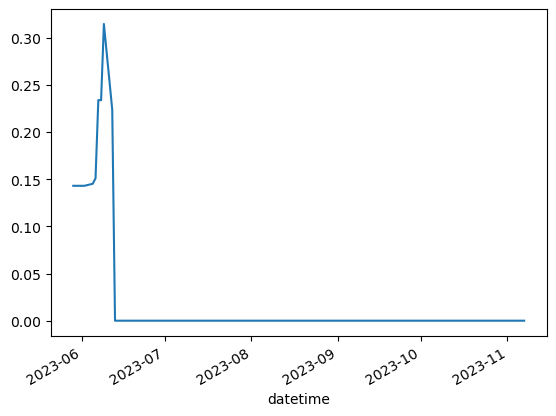

In [98]:
num_units.plot()

In [99]:
positions = market_val.mul(num_units, axis=0)
positions

,FUESSV30,E1VFVN30
datetime,,
2023-04-27,NaN,NaN
2023-04-28,NaN,NaN
2023-05-04,NaN,NaN
2023-05-05,NaN,NaN
2023-05-08,NaN,NaN
...,...,...
2023-11-01,1.981487e-07,-1.323916e-07
2023-11-02,2.213795e-07,-1.638885e-07
2023-11-03,2.086441e-07,-1.534148e-07


In [100]:
pnl = positions.shift(1) * (price - price.shift(1)) / price.shift(1)
pnl = pnl.sum(axis=1)
pnl

datetime
2023-04-27    0.000000e+00
2023-04-28    0.000000e+00
2023-05-04    0.000000e+00
2023-05-05    0.000000e+00
2023-05-08    0.000000e+00
                  ...     
2023-11-01   -5.087447e-09
2023-11-02    3.358383e-09
2023-11-03    2.155112e-09
2023-11-06    1.590169e-09
2023-11-07   -1.280321e-09
Length: 134, dtype: float64

In [101]:
pnl.describe()

count    1.340000e+02
mean     1.363742e-03
std      1.449903e-01
min     -6.886148e-01
25%     -2.356831e-09
50%      0.000000e+00
75%      2.209329e-09
max      1.404506e+00
dtype: float64

In [102]:
ret = pnl / positions.shift(1).sum(axis=1).abs()
ret

datetime
2023-04-27         NaN
2023-04-28         NaN
2023-05-04         NaN
2023-05-05         NaN
2023-05-08         NaN
                ...   
2023-11-01   -0.060975
2023-11-02    0.051073
2023-11-03    0.037486
2023-11-06    0.028792
2023-11-07   -0.020359
Length: 134, dtype: float64

In [103]:
ret.describe()

count    114.000000
mean       0.027414
std        0.335899
min       -0.496521
25%       -0.052977
50%        0.001104
75%        0.037269
max        2.723539
dtype: float64

<Axes: xlabel='datetime'>

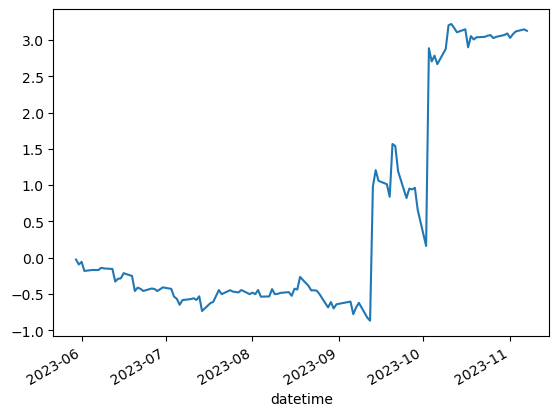

In [104]:
ret.cumsum().plot()

In [105]:
sharp_ratio = math.sqrt(252)*ret.mean()/ret.std()
sharp_ratio

np.float64(1.2955908458043282)

In [106]:
term = pd.DataFrame({
    "ret": ret.cumsum().dropna(),
    'lagged_ret': ret.cumsum().dropna().shift(1),
    'high_watermark_index': ret.cumsum().dropna().index
})
term['lagged_ret'] = term['lagged_ret'].fillna(0)

highest_watermark_index = term.iloc[0]['high_watermark_index']
for d in term.index:
    row = term.loc[d]
    if row['ret'] >= term.loc[highest_watermark_index]['ret']:
        highest_watermark_index = d
    term.loc[d, 'high_watermark_index']= highest_watermark_index

term['high_watermark_ret'] = term.apply(lambda x: term.loc[x['high_watermark_index']]['ret'], axis=1)
term['drawdown_deep'] = term['high_watermark_ret'] - term['ret']
term['drawdown_duration'] = term.index - term['high_watermark_index']
term

,ret,lagged_ret,high_watermark_index,high_watermark_ret,drawdown_deep,drawdown_duration
datetime,,,,,,
2023-05-30,-0.025665,0.000000,2023-05-30,-0.025665,0.000000,0 days
2023-05-31,-0.093718,-0.025665,2023-05-30,-0.025665,0.068053,1 days
2023-06-01,-0.057180,-0.093718,2023-05-30,-0.025665,0.031515,2 days
2023-06-02,-0.182578,-0.057180,2023-05-30,-0.025665,0.156913,3 days
2023-06-05,-0.168585,-0.182578,2023-05-30,-0.025665,0.142920,6 days
...,...,...,...,...,...,...
2023-11-01,3.028229,3.089204,2023-10-11,3.219883,0.191654,21 days
2023-11-02,3.079302,3.028229,2023-10-11,3.219883,0.140582,22 days
2023-11-03,3.116788,3.079302,2023-10-11,3.219883,0.103096,23 days


In [107]:
term.describe()

,ret,lagged_ret,high_watermark_index,high_watermark_ret,drawdown_deep,drawdown_duration
count,114.000000,114.000000,114,114.000000,114.000000,114
mean,0.516087,0.488673,2023-07-12 19:22:06.315789568,0.877438,0.361350,36 days 00:37:53.684210526
min,-0.868092,-0.868092,2023-05-30 00:00:00,-0.025665,0.000000,0 days 00:00:00
25%,-0.502397,-0.502397,2023-05-30 00:00:00,-0.025665,0.154357,7 days 06:00:00
50%,-0.398357,-0.398357,2023-05-30 00:00:00,-0.025665,0.404519,25 days 00:00:00
75%,1.202070,1.157095,2023-09-20 00:00:00,1.566236,0.505357,62 days 18:00:00
max,3.219883,3.219883,2023-10-11 00:00:00,3.219883,1.404194,105 days 00:00:00
std,1.460174,1.439952,NaN,1.331605,0.239116,32 days 05:05:24.613831639


In [108]:
print(term['drawdown_deep'].idxmax())
term.loc[term['drawdown_deep'].idxmax()]

2023-10-02 00:00:00


ret                                0.162042
lagged_ret                         0.658563
high_watermark_index    2023-09-20 00:00:00
high_watermark_ret                 1.566236
drawdown_deep                      1.404194
drawdown_duration          12 days 00:00:00
Name: 2023-10-02 00:00:00, dtype: object

In [109]:
print(term['drawdown_duration'].idxmax())
term.loc[term['drawdown_duration'].idxmax()]

2023-09-12 00:00:00


ret                               -0.868092
lagged_ret                        -0.825888
high_watermark_index    2023-05-30 00:00:00
high_watermark_ret                -0.025665
drawdown_deep                      0.842427
drawdown_duration         105 days 00:00:00
Name: 2023-09-12 00:00:00, dtype: object